# Cell 1: Install packages

In [1]:
!pip -q install imbalanced-learn xgboost shap

# Cell 2: Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.base import clone

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler

from xgboost import XGBClassifier

import shap

RANDOM_STATE = 42

# Cell 3: Load dataset

In [3]:
uploaded = files.upload()

csv_path = list(uploaded.keys())[0]

df = pd.read_csv("/content/HepatitisCdata.csv")

# Remove unnamed index/patient identifier column if present
unnamed_cols = [col for col in df.columns if "Unnamed" in col]
df = df.drop(columns=unnamed_cols, errors="ignore")

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nOriginal class distribution:")
print(df["Category"].value_counts())

Saving HepatitisCdata.csv to HepatitisCdata (1).csv
Dataset shape: (615, 13)


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7



Columns:
['Category', 'Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']

Missing values:
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

Original class distribution:
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64


# Cell 4: Data cleaning and encoding

In [4]:
# Remove duplicate rows
df = df.drop_duplicates()

# Encode Sex: m = 0, f = 1
df["Sex"] = df["Sex"].str.lower().map({"m": 0, "f": 1})

# Encode target variable
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["Category"])

class_names = label_encoder.classes_

print("Encoded class labels:")
for i, label in enumerate(class_names):
    print(i, "=", label)

# Features
X = df.drop(columns=["Category"])

print("\nFeature columns:")
print(X.columns.tolist())

Encoded class labels:
0 = 0=Blood Donor
1 = 0s=suspect Blood Donor
2 = 1=Hepatitis
3 = 2=Fibrosis
4 = 3=Cirrhosis

Feature columns:
['Age', 'Sex', 'ALB', 'ALP', 'ALT', 'AST', 'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT']


# Cell 5: Stratified train-test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Training set shape: (492, 12)
Test set shape: (123, 12)

Training class distribution:
0    426
1      6
2     19
3     17
4     24
Name: count, dtype: int64

Test class distribution:
0    107
1      1
2      5
3      4
4      6
Name: count, dtype: int64


# Cell 6: Class distribution table before and after SMOTE

In [6]:
# This table is for your manuscript Table II

original_counts = pd.Series(y).value_counts().sort_index()
train_before_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

max_train_count = train_before_counts.max()

class_distribution_df = pd.DataFrame({
    "Class": class_names,
    "Original": [original_counts.get(i, 0) for i in range(len(class_names))],
    "Train Before": [train_before_counts.get(i, 0) for i in range(len(class_names))],
    "Train After": [max_train_count for _ in range(len(class_names))],
    "Test": [test_counts.get(i, 0) for i in range(len(class_names))]
})

display(class_distribution_df)

class_distribution_df.to_csv("table_class_distribution.csv", index=False)
print("Saved: table_class_distribution.csv")

,Class,Original,Train Before,Train After,Test
0,0=Blood Donor,533,426,426,107
1,0s=suspect Blood Donor,7,6,426,1
2,1=Hepatitis,24,19,426,5
3,2=Fibrosis,21,17,426,4
4,3=Cirrhosis,30,24,426,6


Saved: table_class_distribution.csv


# Cell 7: Create leakage-safe ML pipeline

In [7]:
n_features_to_select = min(8, X_train.shape[1])

def get_sampler(y_data):
    min_class_count = pd.Series(y_data).value_counts().min()

    if min_class_count > 1:
        return SMOTE(
            random_state=RANDOM_STATE,
            k_neighbors=min(5, min_class_count - 1)
        )
    else:
        return RandomOverSampler(random_state=RANDOM_STATE)


def make_pipeline(model):
    pipeline = Pipeline(steps=[
        ("imputer", KNNImputer(n_neighbors=5)),

        ("scaler", StandardScaler()),

        ("rfe", RFE(
            estimator=LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ),
            n_features_to_select=n_features_to_select
        )),

        ("sampler", get_sampler(y_train)),

        ("model", model)
    ])

    return pipeline

# Cell 8: Define models

In [8]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.90,
        colsample_bytree=0.90,
        eval_metric="mlogloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )
}

# Cell 9: Train all models

In [9]:
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    pipeline = make_pipeline(model)
    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("\nAll models trained successfully.")

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training SVM...

All models trained successfully.


# Cell 10: Overall train and test evaluation

In [10]:
def evaluate_model(model_name, pipeline, X_data, y_true, set_name):
    y_pred = pipeline.predict(X_data)

    try:
        y_prob = pipeline.predict_proba(X_data)

        roc_auc = roc_auc_score(
            y_true,
            y_prob,
            labels=np.arange(len(class_names)),
            multi_class="ovr",
            average="macro"
        )
    except:
        roc_auc = np.nan

    return {
        "Model": model_name,
        "Set": set_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision Macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall Macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC-AUC OVR": roc_auc
    }


results = []

for name, pipeline in trained_models.items():
    results.append(evaluate_model(name, pipeline, X_train, y_train, "Train"))
    results.append(evaluate_model(name, pipeline, X_test, y_test, "Test"))

results_df = pd.DataFrame(results)

display(results_df.round(4))

results_df.to_csv("table_train_test_results.csv", index=False)
print("Saved: table_train_test_results.csv")

,Model,Set,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,MCC,ROC-AUC OVR
0,Logistic Regression,Train,0.8760,0.8017,0.6761,0.8017,0.7151,0.6289,0.9616
1,Logistic Regression,Test,0.8537,0.8205,0.6630,0.8205,0.7091,0.5838,0.9315
2,Random Forest,Train,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest,Test,0.9268,0.6548,0.6630,0.6548,0.6583,0.6842,0.9638
4,XGBoost,Train,0.9492,0.9468,0.7992,0.9468,0.8608,0.8268,0.9968
5,XGBoost,Test,0.8862,0.6455,0.6278,0.6455,0.6343,0.5754,0.9658
6,SVM,Train,0.9350,0.9548,0.7693,0.9548,0.8420,0.7933,0.9930
7,SVM,Test,0.8780,0.7846,0.7208,0.7846,0.7312,0.6140,0.9531


Saved: table_train_test_results.csv


# Cell 11: Test result table only

In [11]:
test_results_df = results_df[results_df["Set"] == "Test"].copy()

test_results_df = test_results_df.sort_values(
    "F1 Macro",
    ascending=False
)

display(test_results_df.round(4))

test_results_df.to_csv("table_test_results.csv", index=False)
print("Saved: table_test_results.csv")

,Model,Set,Accuracy,Balanced Accuracy,Precision Macro,Recall Macro,F1 Macro,MCC,ROC-AUC OVR
7,SVM,Test,0.8780,0.7846,0.7208,0.7846,0.7312,0.6140,0.9531
1,Logistic Regression,Test,0.8537,0.8205,0.6630,0.8205,0.7091,0.5838,0.9315
3,Random Forest,Test,0.9268,0.6548,0.6630,0.6548,0.6583,0.6842,0.9638
5,XGBoost,Test,0.8862,0.6455,0.6278,0.6455,0.6343,0.5754,0.9658


Saved: table_test_results.csv


# Cell 12: Classification report for all models

In [12]:
for name, pipeline in trained_models.items():
    print("=" * 80)
    print(f"TEST CLASSIFICATION REPORT: {name}")
    print("=" * 80)

    y_test_pred = pipeline.predict(X_test)

    print(classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        zero_division=0
    ))

TEST CLASSIFICATION REPORT: Logistic Regression
                        precision    recall  f1-score   support

         0=Blood Donor       0.99      0.87      0.93       107
0s=suspect Blood Donor       1.00      1.00      1.00         1
           1=Hepatitis       0.17      0.40      0.24         5
            2=Fibrosis       0.44      1.00      0.62         4
           3=Cirrhosis       0.71      0.83      0.77         6

              accuracy                           0.85       123
             macro avg       0.66      0.82      0.71       123
          weighted avg       0.92      0.85      0.88       123

TEST CLASSIFICATION REPORT: Random Forest
                        precision    recall  f1-score   support

         0=Blood Donor       0.98      0.99      0.99       107
0s=suspect Blood Donor       1.00      1.00      1.00         1
           1=Hepatitis       0.25      0.20      0.22         5
            2=Fibrosis       0.25      0.25      0.25         4
          

# Cell 13: Correct Random Forest per-class table

In [13]:
rf_model = trained_models["Random Forest"]

y_test_pred_rf = rf_model.predict(X_test)

rf_report = classification_report(
    y_test,
    y_test_pred_rf,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

rf_per_class_df = pd.DataFrame(rf_report).transpose()

rf_per_class_df = rf_per_class_df.loc[class_names, ["precision", "recall", "f1-score", "support"]]

display(rf_per_class_df.round(4))

rf_per_class_df.to_csv("table_rf_per_class_results.csv")
print("Saved: table_rf_per_class_results.csv")

,precision,recall,f1-score,support
0=Blood Donor,0.9815,0.9907,0.9860,107.0
0s=suspect Blood Donor,1.0000,1.0000,1.0000,1.0
1=Hepatitis,0.2500,0.2000,0.2222,5.0
2=Fibrosis,0.2500,0.2500,0.2500,4.0
3=Cirrhosis,0.8333,0.8333,0.8333,6.0


Saved: table_rf_per_class_results.csv


# Cell 14: Correct Random Forest confusion matrix

Confusion Matrix:
[[106   0   1   0   0]
 [  0   1   0   0   0]
 [  1   0   1   2   1]
 [  1   0   2   1   0]
 [  0   0   0   1   5]]

Row sums must match test set class support:
Row sums: [107   1   5   4   6]
Test support: [107   1   5   4   6]


<Figure size 700x600 with 0 Axes>

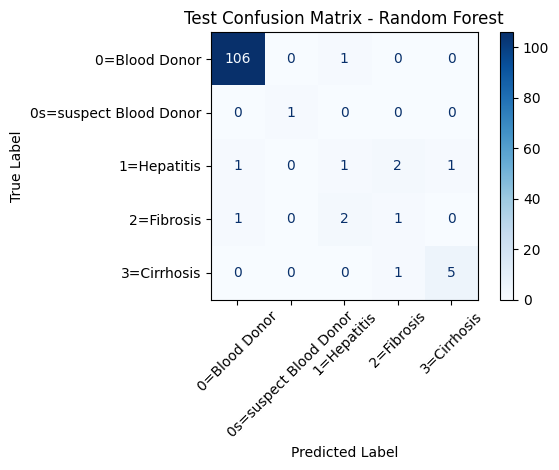

Saved: fig2_confusion_matrix_rf.png


In [14]:
rf_model = trained_models["Random Forest"]

# IMPORTANT:
# This prediction is on the untouched test set only.
y_test_pred_rf = rf_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_test_pred_rf,
    labels=np.arange(len(class_names))
)

print("Confusion Matrix:")
print(cm)

print("\nRow sums must match test set class support:")
print("Row sums:", cm.sum(axis=1))
print("Test support:", pd.Series(y_test).value_counts().sort_index().values)

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d",
    xticks_rotation=45
)

plt.title("Test Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

plt.savefig("fig2_confusion_matrix_rf.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig2_confusion_matrix_rf.png")

# Cell 15: Download fixed confusion matrix

In [15]:
files.download("fig2_confusion_matrix_rf.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 16: Helper functions for SHAP with real feature names

In [16]:
def get_selected_features(pipeline):
    rfe_support = pipeline.named_steps["rfe"].support_
    selected_features = X_train.columns[rfe_support].tolist()
    return selected_features


def transform_data_for_shap(pipeline, X_data):
    """
    Apply only fitted preprocessing:
    KNN Imputer -> StandardScaler -> RFE

    SMOTE is not applied to test data.
    """
    X_imputed = pipeline.named_steps["imputer"].transform(X_data)
    X_scaled = pipeline.named_steps["scaler"].transform(X_imputed)
    X_selected = pipeline.named_steps["rfe"].transform(X_scaled)

    return X_selected

# Cell 17: Check selected feature names

In [17]:
for name, pipeline in trained_models.items():
    selected_features = get_selected_features(pipeline)
    print(name, "selected features:")
    print(selected_features)
    print()

Logistic Regression selected features:
['Sex', 'ALB', 'ALT', 'AST', 'BIL', 'CHE', 'GGT', 'PROT']

Random Forest selected features:
['Sex', 'ALB', 'ALT', 'AST', 'BIL', 'CHE', 'GGT', 'PROT']

XGBoost selected features:
['Sex', 'ALB', 'ALT', 'AST', 'BIL', 'CHE', 'GGT', 'PROT']

SVM selected features:
['Sex', 'ALB', 'ALT', 'AST', 'BIL', 'CHE', 'GGT', 'PROT']



# Cell 18: Calculate SHAP values for all models

In [18]:
BACKGROUND_SIZE = 40
EXPLAIN_SIZE = 60

combined_shap_results = []

for model_name, pipeline in trained_models.items():

    print("=" * 80)
    print(f"Calculating SHAP for {model_name}")
    print("=" * 80)

    model = pipeline.named_steps["model"]
    selected_features = get_selected_features(pipeline)

    X_train_selected = transform_data_for_shap(pipeline, X_train)
    X_test_selected = transform_data_for_shap(pipeline, X_test)

    X_train_shap = pd.DataFrame(
        X_train_selected,
        columns=selected_features
    )

    X_test_shap = pd.DataFrame(
        X_test_selected,
        columns=selected_features
    )

    background = X_train_shap.sample(
        n=min(BACKGROUND_SIZE, len(X_train_shap)),
        random_state=RANDOM_STATE
    )

    explain_data = X_test_shap.sample(
        n=min(EXPLAIN_SIZE, len(X_test_shap)),
        random_state=RANDOM_STATE
    )

    def predict_function(data):
        data = np.array(data)
        return model.predict_proba(data)

    explainer = shap.Explainer(
        predict_function,
        background,
        feature_names=selected_features
    )

    shap_values = explainer(explain_data)

    values = shap_values.values

    # Multiclass shape usually: samples x features x classes
    if len(values.shape) == 3:
        mean_abs_shap = np.abs(values).mean(axis=(0, 2))
    else:
        mean_abs_shap = np.abs(values).mean(axis=0)

    for feature, value in zip(selected_features, mean_abs_shap):
        combined_shap_results.append({
            "Model": model_name,
            "Feature": feature,
            "Mean Absolute SHAP": value
        })

combined_shap_df = pd.DataFrame(combined_shap_results)

display(combined_shap_df.round(4))

combined_shap_df.to_csv("table_combined_shap_values.csv", index=False)
print("Saved: table_combined_shap_values.csv")

Calculating SHAP for Logistic Regression
Calculating SHAP for Random Forest
Calculating SHAP for XGBoost
Calculating SHAP for SVM


ExactExplainer explainer: 61it [00:39,  1.17it/s]


,Model,Feature,Mean Absolute SHAP
0,Logistic Regression,Sex,0.0150
1,Logistic Regression,ALB,0.0283
2,Logistic Regression,ALT,0.0217
3,Logistic Regression,AST,0.0999
4,Logistic Regression,BIL,0.0172
5,Logistic Regression,CHE,0.0298
6,Logistic Regression,GGT,0.0244
7,Logistic Regression,PROT,0.0107
8,Random Forest,Sex,0.0083
9,Random Forest,ALB,0.0159


Saved: table_combined_shap_values.csv


# Cell 19: Combined SHAP graph for all models

<Figure size 900x600 with 0 Axes>

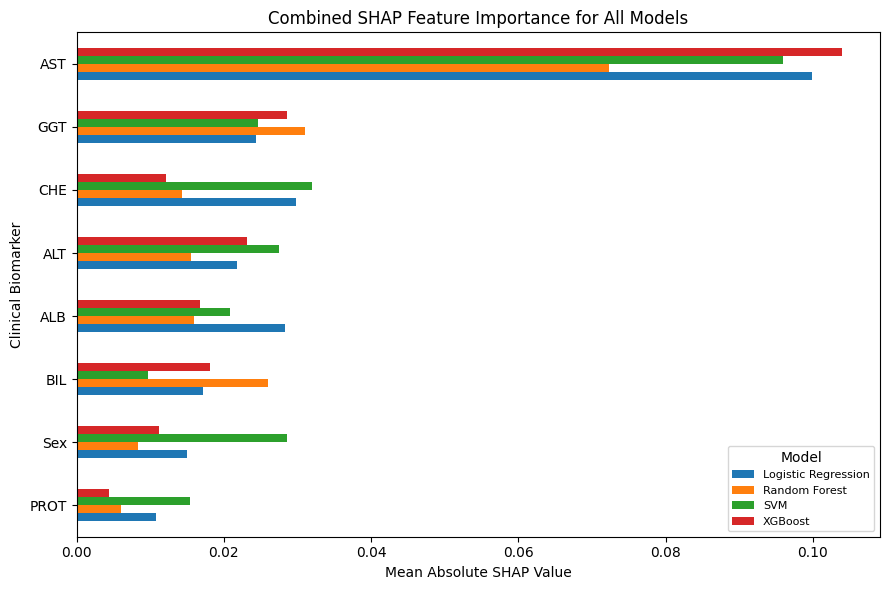

Saved: fig3_combined_shap.png


In [19]:
shap_pivot = combined_shap_df.pivot_table(
    index="Feature",
    columns="Model",
    values="Mean Absolute SHAP",
    fill_value=0
)

# Sort features by average SHAP importance across all models
shap_pivot["Average SHAP"] = shap_pivot.mean(axis=1)
shap_pivot = shap_pivot.sort_values("Average SHAP", ascending=True)

shap_plot_df = shap_pivot.drop(columns=["Average SHAP"])

plt.figure(figsize=(9, 6))

shap_plot_df.plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Combined SHAP Feature Importance for All Models")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Clinical Biomarker")
plt.legend(title="Model", fontsize=8)
plt.tight_layout()

plt.savefig("fig3_combined_shap.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: fig3_combined_shap.png")

# Cell 20: Download fixed SHAP graph

In [20]:
files.download("fig3_combined_shap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Cell 21: Optional download all tables

In [21]:
files.download("table_class_distribution.csv")
files.download("table_test_results.csv")
files.download("table_rf_per_class_results.csv")
files.download("table_combined_shap_values.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>